In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os

In [2]:
INPUT_DIR = "../inputs/"

# List all files in the input directory
files = os.listdir(INPUT_DIR)

def get_mat_dims(input_file_name):
    # File name is of the form "input_matrix_{nrows:04d}_{ncols:04d}.bin"
    parts = input_file_name.replace(".bin", "").split("_")
    nrows, ncols = int(parts[2]), int(parts[3])
    return nrows, ncols

MAT_DIMS = [get_mat_dims(f) for f in files]

# Sort MAT_DIMS by the product of nrows and ncols
MAT_DIMS.sort(key=lambda x: x[0] * x[1])

print(MAT_DIMS)

[(76, 76), (13, 620), (69, 153), (100, 150), (150, 150), (150, 200), (200, 200), (200, 250), (250, 250), (300, 300), (585, 196), (168, 742), (391, 391), (455, 338), (137, 1163), (633, 633), (1264, 349), (592, 1618), (1221, 1150), (1308, 1308), (1514, 1514), (1655, 1594)]


In [3]:
def get_time_from_log(log_file_name):
    with open(log_file_name, "r") as f:
        lines = f.readlines()

    # Rstrip '\n' from each line
    lines = [line.rstrip() for line in lines]

    if lines[0] == "PASSED":
        tm_taken = float(lines[1].split()[-2]) / 1000.0
        return tm_taken
    return None

In [ ]:
NUM_THRS = 8

def plot_algo(algo):
    mat_dims = []
    tms = []
    for i, (nrows, ncols) in enumerate(MAT_DIMS):
        log_file_name = f"exp1_logs/log_{nrows:04d}_{ncols:04d}_{algo}.txt"
        if os.path.exists(log_file_name):
            tm = get_time_from_log(log_file_name)
            if tm is not None:
                mat_dims.append((nrows, ncols))
                tms.append(tm)
            else:
                print(f"Test failed for {nrows}x{ncols} matrix")

    mat_sizes = [x[0] * x[1] for x in mat_dims]
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.rcParams.update({'font.size': 14})
    plt.plot(mat_sizes, tms, marker='o', label=algo.upper())
    plt.xscale("log")
    # plt.yscale("log")
    # Set font size to 14
    plt.xticks(mat_sizes, [f"{nrows}x{ncols}" for nrows, ncols in mat_dims], rotation=90)
    # plt.xticks(range(len(mat_dims)), [f"{nrows}x{ncols}" for nrows, ncols in mat_dims], rotation=90)
    plt.xticks(fontsize=12)
    plt.title(f"Time taken vs Matrix Size ({NUM_THRS} threads)")
    plt.xlabel("Matrix Size (nrows x ncols) (log scale)")
    plt.ylabel("Time taken (ms)")
    plt.grid()
    plt.tight_layout()
    plt.legend()
    plt.show()

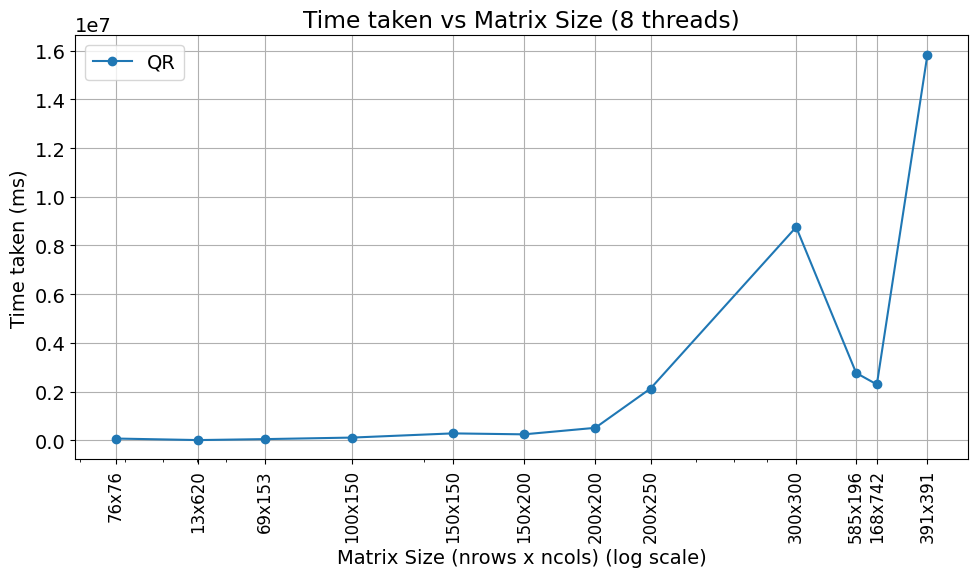

In [47]:
plot_algo("qr")

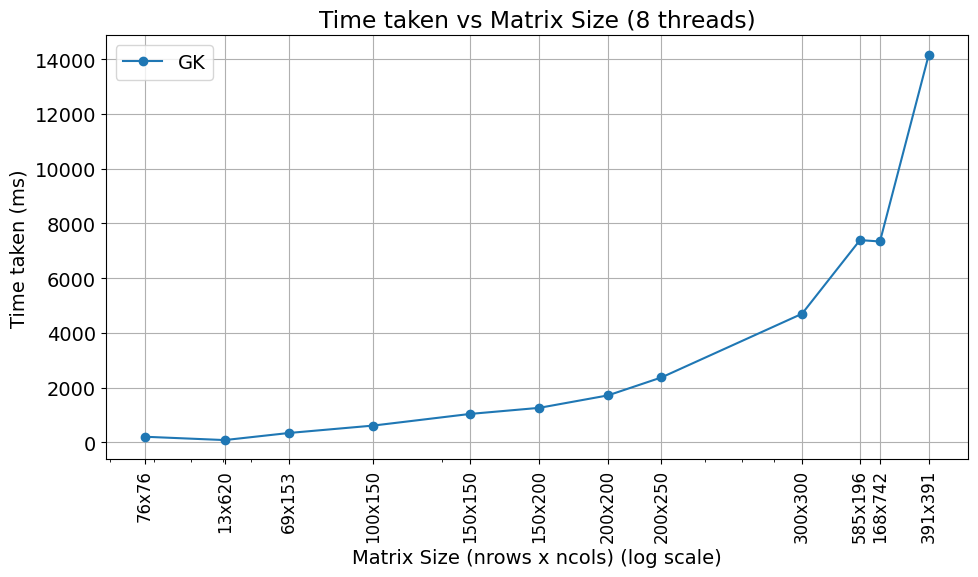

In [48]:
plot_algo("gk")

# Plot experiment 2

In [43]:
def plot_exp2(algo, log_dir, nrows = 200, ncols = 200):
    num_thrs = []

    tms = []

    fls = os.listdir(log_dir)
    for f in fls:
        if f.startswith(f"log_{nrows:04d}_{ncols:04d}") and f.endswith(f"_{algo}.txt"):
            tm = get_time_from_log(f"{log_dir}/{f}")
            if tm is not None:
                tms.append(tm)
                num_thrs.append(int(f.split("_")[3]))
            else:
                print(f"Test failed for {nrows}x{ncols} matrix")

    print(num_thrs)
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.rcParams.update({'font.size': 14})
    plt.plot(num_thrs, tms, marker='o', label=algo.upper())
    # xscale should be log2
    plt.xscale("log", base=2)
    plt.title(f"Time taken vs Number of Threads ({nrows}x{ncols} matrix)")
    plt.xlabel("Number of Threads (log scale)")
    plt.ylabel("Time taken (ms)")
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

[1, 2, 4, 8, 16, 32]


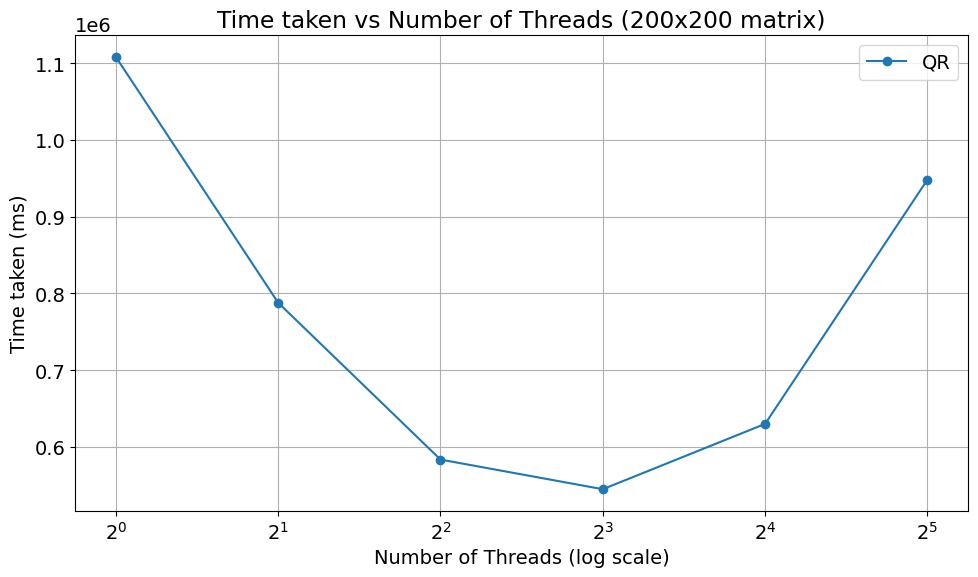

In [44]:
plot_exp2("qr", "exp2_logs_2")

[1, 2, 4, 8, 16, 32]


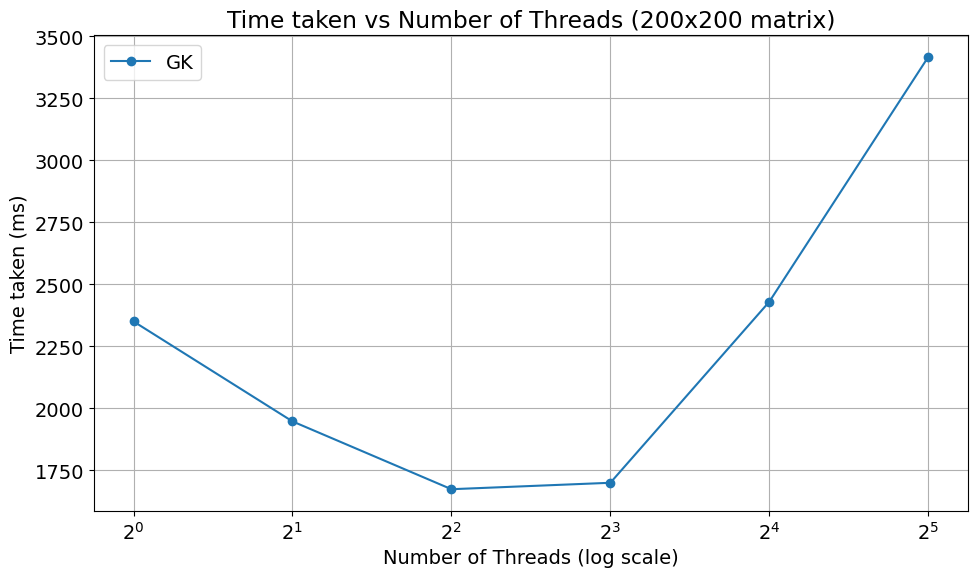

In [45]:
plot_exp2("gk", "exp2_logs_2")

[1, 2, 4, 8, 16, 32]


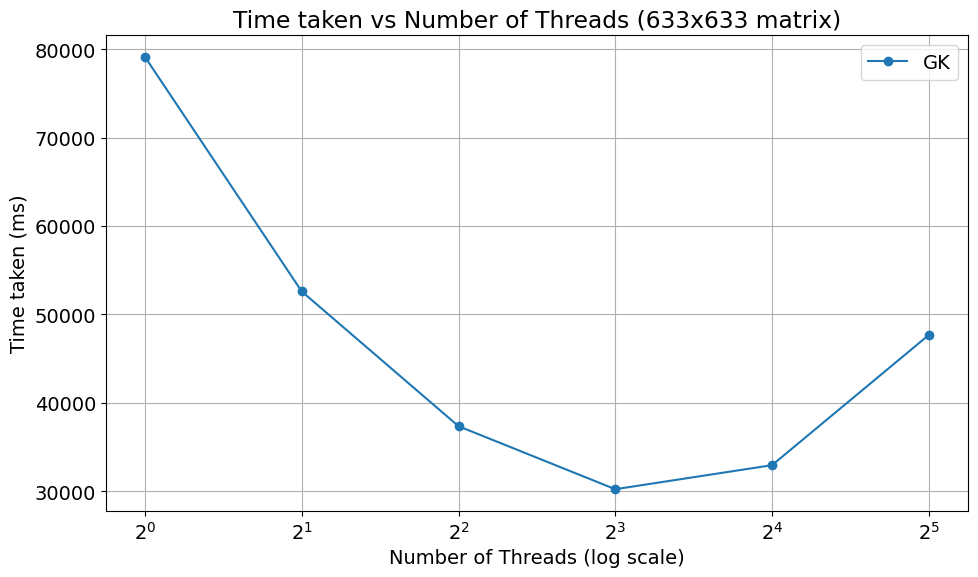

In [46]:
plot_exp2("gk", "exp2_logs_gk", nrows=633, ncols=633)